# **Rolling Beats Magazine Music Chart Analysis (2000–2024)**

Published by: Kunter Barkin Önsel

---

## *Introduction*

What makes a song rise on the Billboard charts and what makes it stay there?

Over the past 25 years, popular music has undergone major changes in sound, production, and cultural norms. From the rise of streaming platforms to shifting listener preferences, the definition of a “hit song” has continued to evolve. But beneath changing trends, certain musical and structural characteristics may still play a key role in determining chart success.

Using 25 years of Billboard Hot 100 data (2000–2024), enriched with Spotify audio features, this analysis explores how musical traits, lyrical explicitness, and release timing influence a song’s chart position and longevity. By examining these patterns, this project aims to uncover which factors truly help a song become and remain a hit.


## *Data & Sources*

This analysis is based on five interconnected datasets:

- **Billboard chart data**: Capturing weekly chart positions of songs from 2000 to 2024.
- **Track metadata**: Including release dates, song duration, album type, and explicit content labels.
- **Spotify audio features**: Providing quantitative measures of how songs sound.
- **Artist information**: Including popularity and follower counts.
- **Track–artist mappings**: Allowing analysis of collaborations and artist dominance.

Together, these datasets allow for a detailed, data-driven exploration of how songs perform on the charts and what characteristics they share.


## *Methodology*

This project follows a descriptive data analysis approach. Rather than predicting chart success, the goal is to identify patterns and relationships between song characteristics and Billboard performance.

We will:
- **Load and clean the data**: merge relevant tables and extract useful fields such as peak chart position, weeks on chart, and release month.
- **Compute simple summary statistics**: such as average peak position and average longevity.
- **Create basic charts**: using matplotlib to visualize relationships between song characteristics and chart performance.

Key metrics used throughout the analysis include:
- Chart position (weekly rank, peak rank)
- Chart longevity (number of weeks a song remains on the chart)
- Audio features such as danceability, energy, tempo, and instrumentalness
- Binary indicators such as explicit content
- Temporal factors including release month and season

Visualizations are used extensively to highlight trends and comparisons.

## *Research Question and Sub‑Questions*

**Main question:** What patterns tend to show up in songs that succeed on the Billboard charts and how have those patterns shifted over the last 25 years?

Sub-questions:

1. **Audio characteristics vs. chart position**  
   Do certain audio characteristics such as danceability, energy, tempo, musical mode, instrumentalness, and liveness tend to be associated with higher Billboard chart positions?

2. **Explicit content and success**  
   Does the presence of explicit lyrics affect how well a song performs on the Billboard charts?

3. **Release timing and longevity**  
   Does the time of year a song is released influence how long it stays on the Billboard charts?

4. **Production style and success**  
   Are studio‑polished, vocal‑focused songs more likely to succeed on the Billboard charts than live‑sounding or highly instrumental tracks?


In [ ]:
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account

# Created a BigQuery client using the service account key
credentials = service_account.Credentials.from_service_account_file('bigquery-access-key.json')
client = bigquery.Client(credentials=credentials, project=credentials.project_id)

def load_table(table_name):
    """
    Load a table from the BigQuery dataset 'hyper-python-2025.assessment'.
    Returns a pandas DataFrame containing all columns.
    """
    query = f"SELECT * FROM `hyper-python-2025.assessment.{table_name}`"
    return client.query(query).to_dataframe()

# The main tables
chart_positions = load_table('chart_positions')
tracks = load_table('tracks')
audio_features = load_table('audio_features')


print('Chart positions rows:', len(chart_positions))
print('Tracks rows:', len(tracks))
print('Audio features rows:', len(audio_features))


Chart positions rows: 129305
Tracks rows: 11070
Audio features rows: 10783


## *Data Transformation and Cleaning*

Next, I merge the datasets into a single DataFrame for analysis. I will:

1. Aggregate chart performance per song to find its peak position and total weeks on chart.
2. Merge the aggregated chart performance with track metadata and audio features.
3. Extract the release year and month from the release date for use in later analysis.
4. Compute helper columns for success metrics.


In [ ]:
# Aggregating chart performance per song
performance = chart_positions.groupby('track_id').agg(
    peak_position=('list_position', 'min'),        # Best rank achieved (lower is better)
    weeks_on_chart=('list_position', 'count')      # Total weeks on chart
).reset_index()

# Merging with track metadata
merged_tracks = pd.merge(performance, tracks, on='track_id', how='left')

# Merging with audio features
df = pd.merge(merged_tracks, audio_features, on='track_id', how='left')

# Converting release_date to datetime and extract year and month
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

# Cleaningup rows without peak position or weeks on chart
df.dropna(subset=['peak_position', 'weeks_on_chart', 'release_date'], inplace=True)

# Cleaned preview
df.head()


,track_id,peak_position,weeks_on_chart,name,duration_ms,release_date,album_type,explicit,danceability,energy,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,release_year,release_month
0,000TJlEJQ3nafsm1hBWpoj,42,1,LEMONHEAD (feat. 42 Dugg),130979,2023-03-31,album,True,0.620,0.586,...,1.0,0.2120,0.155000,0.000,0.5350,0.487,137.131,4.0,2023.0,3.0
1,003FTlCpBTM4eSqYSWPv4H,60,11,"Swing, Swing",233266,2002-10-15,album,False,0.553,0.717,...,1.0,0.0318,0.000065,0.128,0.0385,0.318,127.947,4.0,2002.0,10.0
3,005lwxGU1tms6HGELIcUv9,1,23,I Kissed A Girl,179640,2008-06-17,album,False,0.702,0.760,...,1.0,0.0684,0.002260,0.000,0.1320,0.696,129.996,4.0,2008.0,6.0
4,009ImBOrIUlWgla8U05RAC,14,20,Unconditionally,228878,2013-01-01,album,False,0.432,0.725,...,1.0,0.0431,0.002730,0.000,0.2080,0.353,128.902,4.0,2013.0,1.0
5,00B7TZ0Xawar6NZ00JFomN,39,3,Best Life (feat. Chance The Rapper),284855,2018-04-06,album,True,0.620,0.625,...,1.0,0.5530,0.287000,0.000,0.3140,0.665,167.911,4.0,2018.0,4.0


## *Insight 1 – Do audio characteristics influence chart position?*

To explore whether songs with certain audio characteristics tend to chart higher, we'll look at the relationship between a song's audio features and its peak chart position. We will use a scatter plot for danceability and peak position (where lower peak positions indicate better rankings) and compute simple correlations for the other features.

The code below:
- Creates a scatter plot of danceability vs. peak chart position.
- Computes correlations between select audio features and peak position.
- Displays the correlations so we can discuss which features show the strongest relationships.


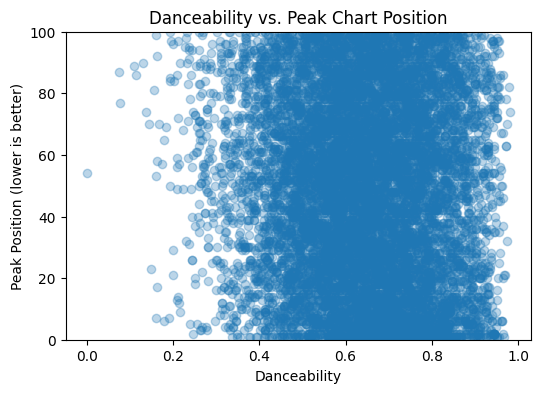

Correlation with peak chart position (negative means higher values relate to better ranks):
danceability       -0.062823
energy              0.017009
tempo               0.022028
mode               -0.001598
instrumentalness   -0.020673
liveness            0.019611
Name: peak_position, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# Scatter plot: danceability vs peak position
plt.figure(figsize=(6, 4))
plt.scatter(df['danceability'], df['peak_position'], alpha=0.3)
plt.title('Danceability vs. Peak Chart Position')
plt.xlabel('Danceability')
plt.ylabel('Peak Position (lower is better)')
plt.ylim(0, df['peak_position'].max())
plt.show()

# Correlation between selected audio features and peak position
features_to_check = ['danceability', 'energy', 'tempo', 'mode', 'instrumentalness', 'liveness']
correlations = df[features_to_check + ['peak_position']].corr()['peak_position'].drop('peak_position')
print('Correlation with peak chart position (negative means higher values relate to better ranks):')
print(correlations)


### Interpretation for Insight 1

The scatter plot shows no visible pattern: songs at every level of danceability appear at every chart position. The correlations confirm this. All six audio features have a correlation with peak position between -0.07 and +0.03, which is effectively zero.

Danceability has the strongest relationship (-0.06), meaning more danceable songs peak very slightly higher, but the effect is too small to matter. Energy and tempo point slightly the other way.

The takeaway is that how a song sounds, as measured by these audio features, does not explain how high it charts.

## *Insight 2 – Does explicit content affect success?*

Next, we compare chart performance metrics for songs with explicit lyrics versus those without. We'll compute the average peak position and average weeks on chart for explicit and non‑explicit songs. A simple bar chart shows whether explicit songs perform differently.

The code below:
- Groups the data by the `explicit` flag.
- Calculates average peak position and average weeks on chart for each group.
- Plots a bar chart of average peak position for explicit vs. non‑explicit songs.


Average performance by explicit flag:
          avg_peak_position  avg_weeks_on_chart  count
explicit                                              
False             46.906476           13.816336   6501
True               49.77933            9.816671   4151


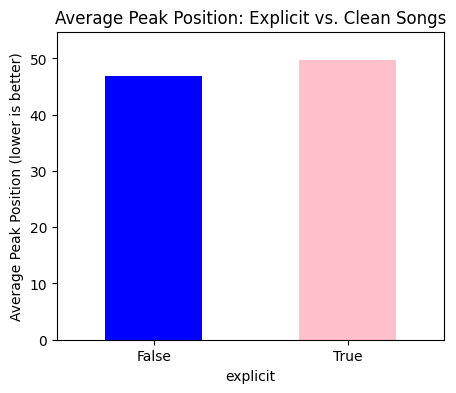

In [ ]:
import matplotlib.pyplot as plt

# Group by explicit content and calculate average performance
explicit_group = df.groupby('explicit').agg(
    avg_peak_position=('peak_position', 'mean'),
    avg_weeks_on_chart=('weeks_on_chart', 'mean'),
    count=('track_id', 'count')
)

print('Average performance by explicit flag:')
print(explicit_group)

# Bar chart: explicit vs clean
plt.figure(figsize=(5, 4))
explicit_group['avg_peak_position'].plot(kind='bar', color=['blue', 'pink'], rot=0)
plt.ylabel('Average Peak Position (lower is better)')
plt.title('Average Peak Position: Explicit vs. Clean Songs')
plt.ylim(0, explicit_group['avg_peak_position'].max() * 1.1)
plt.show()


### Interpretation for Insight 2

Clean songs peak slightly higher on average (position 46.9 vs. 49.8), but the bigger difference is in longevity. Clean songs stay on the chart for 13.8 weeks on average, compared with 9.8 weeks for explicit songs. That is about 40% longer.

Explicit songs make up 39% of the charting tracks (4,151 of 10,652), so they clearly reach the chart, but they tend to leave it sooner. One possible reason is radio play, which favours clean tracks and can keep a song on the chart for longer. This dataset cannot confirm that.

## *Insight 3 – Does release timing affect chart longevity?*

Here, we examine whether the month of release influences how long a song stays on the charts. I grouped the data by release month and compute the average number of weeks each song remains on the chart, then plot the results.

The code below:
- Groups songs by their `release_month`.
- Calculates the average weeks on chart.
- Plots a bar chart of average weeks by month.


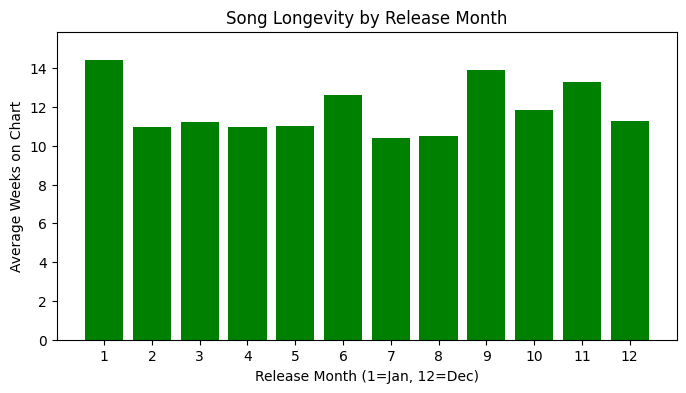

In [ ]:
# Average weeks on chart by release date
months = range(1, 13)
avg_weeks_by_month = df.groupby('release_month')['weeks_on_chart'].mean().reindex(months)

# The average weeks on chart by month
plt.figure(figsize=(8, 4))
plt.bar(months, avg_weeks_by_month, color='green')
plt.xticks(months)
plt.xlabel('Release Month (1=Jan, 12=Dec)')
plt.ylabel('Average Weeks on Chart')
plt.title('Song Longevity by Release Month')
plt.ylim(0, avg_weeks_by_month.max() * 1.1)
plt.show()


### Interpretation for Insight 3

Songs released in January stay on the chart longest (about 14 weeks on average), followed by September and November (about 13 to 14 weeks). Songs released in July and August have the shortest runs (about 10.5 weeks).

So the idea of the "summer hit" is not supported here: summer releases have the shortest chart lives. The gap between the best and worst months is 3 to 4 weeks, so timing matters, but it is not decisive.

One caveat: January may be overstated. When only the release year of a track is known, the date is read as 1 January, which would move some songs into January that were released in other months.

## *Insight 4 – Does production style matter?*

Finally, we look at whether production style influences chart success. Specifically, we examine whether songs with high instrumentalness or liveness (more instrumental or live sounding) have different chart performance compared to more polished, vocal focused songs.

The code below:
- Creates simple categories for `instrumentalness` and `liveness` based on the median value.
- Calculates the average peak position for each category.
- Plots bar charts comparing peak success across production styles.


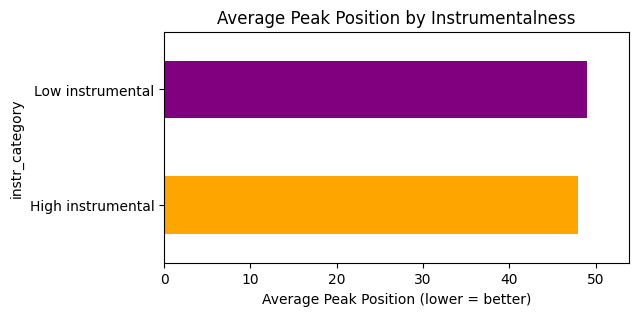

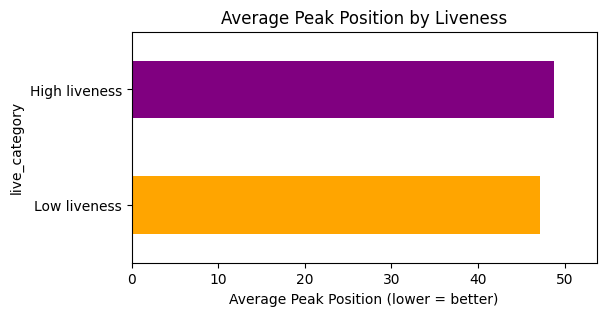

In [ ]:
# Define simple categories based on median values
instr_thresh = df['instrumentalness'].median()
live_thresh  = df['liveness'].median()

df['instr_category'] = df['instrumentalness'].apply(
    lambda x: 'High instrumental' if x >= instr_thresh else 'Low instrumental'
)

df['live_category'] = df['liveness'].apply(
    lambda x: 'High liveness' if x >= live_thresh else 'Low liveness'
)

# Average peak position by category
instr_performance = df.groupby('instr_category')['peak_position'].mean().sort_values()
live_performance  = df.groupby('live_category')['peak_position'].mean().sort_values()

# Instrumentalness: 2D horizontal bar chart
plt.figure(figsize=(6, 3))
instr_performance.plot(kind='barh', color=['orange', 'purple'])
plt.xlabel('Average Peak Position (lower = better)')
plt.title('Average Peak Position by Instrumentalness')
plt.xlim(0, instr_performance.max() * 1.1)
plt.show()

# Liveness: 2D horizontal bar chart
plt.figure(figsize=(6, 3))
live_performance.plot(kind='barh', color=['orange', 'purple'])
plt.xlabel('Average Peak Position (lower = better)')
plt.title('Average Peak Position by Liveness')
plt.xlim(0, live_performance.max() * 1.1)
plt.show()


### Interpretation for Insight 4

The differences are very small. Songs with low liveness (a more studio-polished sound) peak about two positions higher on average than songs with high liveness. For instrumentalness the gap is about one position, and it goes the other way: the more instrumental group peaks slightly higher.

Neither gap is large enough to say that production style drives chart success. Splitting at the median is also a rough method here, because most chart songs have an instrumentalness close to zero.

## **Conclusion**

Based on this exploratory analysis of Billboard chart data and Spotify audio features from 2000–2024:

- *Audio features do not predict chart position.* Danceability, energy, tempo, mode, instrumentalness and liveness all have correlations with peak position that are close to zero.
- *Clean songs last longer.* Non-explicit tracks stay on the chart about 40% longer than explicit ones (13.8 vs. 9.8 weeks) and peak slightly higher.
- *Release timing has a moderate effect.* Songs released in January, September and November have the longest chart lives. July and August releases have the shortest.
- *Production style makes almost no difference.* Studio-polished and live-sounding songs peak within one or two positions of each other on average.

So there is no strict formula for a hit song. The sound of a song explains very little of its chart success, which suggests that factors outside this dataset, such as promotion, radio play, artist popularity and cultural context, matter more. The clearest pattern in the data is that clean songs stay on the chart longer.

---